In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

preprocessor = joblib.load("../models/preprocessor.pkl")
ridge_tuned = joblib.load("../models/ridge_tuned.pkl")

print("Best alpha:", ridge_tuned.alpha)

Best alpha: 20.0


In [2]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

final_model = Ridge(alpha=ridge_tuned.alpha, random_state=42)
final_model.fit(X_train_processed, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",20.0
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"po

In [3]:
y_pred_log = final_model.predict(X_test_processed)

# Convert both back to dollar scale
y_pred_dollar = np.expm1(y_pred_log)
y_test_dollar = np.expm1(y_test)

In [4]:
mae = mean_absolute_error(y_test_dollar, y_pred_dollar)
rmse = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))
r2 = r2_score(y_test_dollar, y_pred_dollar)

# RMSLE - Root Mean Squared Log Error
rmsle = np.sqrt(mean_squared_error(y_test, y_pred_log))

print("FINAL TEST SET PERFORMANCE (never seen before)")
print(f"MAE:   ${mae:,.0f}")
print(f"RMSE:  ${rmse:,.0f}")
print(f"R²:    {r2:.4f}")
print(f"RMSLE: {rmsle:.4f}")

FINAL TEST SET PERFORMANCE (never seen before)
MAE:   $13,908
RMSE:  $19,155
R²:    0.9332
RMSLE: 0.1205


In [5]:
cv_rmse_log = 0.1140  # from Phase 14, Ridge tuned CV RMSE (log-scale)

test_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"\nCV RMSE (log-scale, from Phase 14): {cv_rmse_log:.4f}")
print(f"Test RMSE (log-scale, this phase):   {test_rmse_log:.4f}")


CV RMSE (log-scale, from Phase 14): 0.1140
Test RMSE (log-scale, this phase):   0.1205


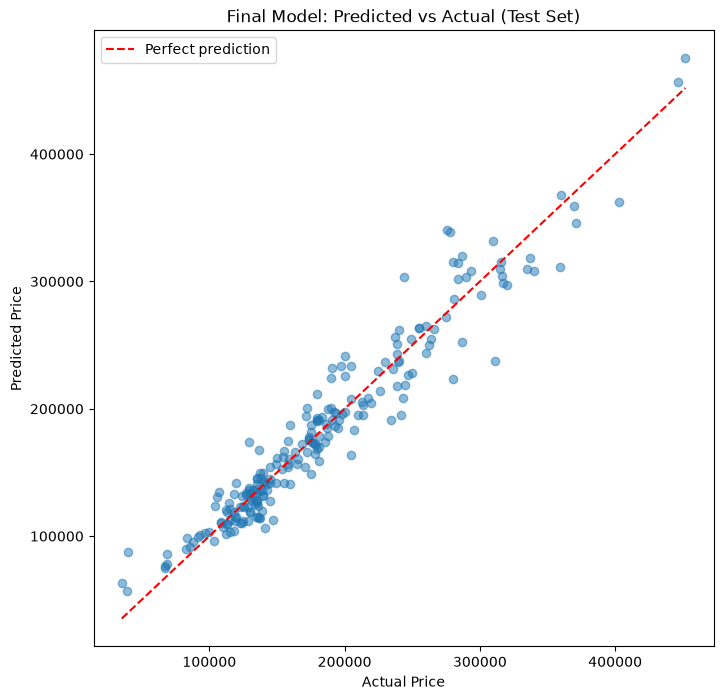

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test_dollar, y_pred_dollar, alpha=0.5)
plt.plot([y_test_dollar.min(), y_test_dollar.max()],
         [y_test_dollar.min(), y_test_dollar.max()],
         color='red', linestyle='--', label='Perfect prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Final Model: Predicted vs Actual (Test Set)")
plt.legend()
plt.show()

In [7]:
final_report = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2', 'RMSLE'],
    'Value': [mae, rmse, r2, rmsle]
})
final_report.to_csv("../models/final_model_report.csv", index=False)
print(final_report)

  Metric         Value
0    MAE  13908.214128
1   RMSE  19155.281046
2     R2      0.933206
3  RMSLE      0.120475


In [8]:
cv_rmse_log = 0.1140  # from Phase 14, Ridge tuned CV RMSE (log-scale)

test_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"CV RMSE (log-scale, from Phase 14): {cv_rmse_log:.4f}")
print(f"Test RMSE (log-scale, this phase):   {test_rmse_log:.4f}")

CV RMSE (log-scale, from Phase 14): 0.1140
Test RMSE (log-scale, this phase):   0.1205
